In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
uc_bmw = pd.read_csv("bmw.csv")

In [3]:
uc_bmw.shape

(10781, 9)

In [4]:
uc_bmw.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [5]:
uc_bmw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [6]:
uc_bmw.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [7]:
def skalenniveau_bestimmen(uc_bmw):
    if uc_bmw.dtype == 'object':  # Kategorische Daten
        # Falls es nur wenige eindeutige Werte gibt, könnte es Nominal oder Ordinal sein.
        unique_values = uc_bmw.nunique()
        if unique_values <= 10:
            return "Nominal (kategorisch)"
        else:
            return "Ordinal (Reihenfolge vorhanden)"
    
    elif pd.api.types.is_numeric_dtype(uc_bmw):
        if (uc_bmw.min() == 0) and (uc_bmw.max() > 0):  # Echte Null vorhanden (Verhältnisskala)
            return "Verhältnisskala"
        else:  # Intervalldaten
            return "Intervallskala"
    
    return "Unklar"

# Beispiel anwenden
print('model', skalenniveau_bestimmen(uc_bmw['model']))  # Nominal
print('year', skalenniveau_bestimmen(uc_bmw['year']))  # Verhältnisskala
print('price', skalenniveau_bestimmen(uc_bmw['price']))  # Ordinal
print('transmission', skalenniveau_bestimmen(uc_bmw['transmission']))  # Verhältnisskala
print('mileage', skalenniveau_bestimmen(uc_bmw['mileage']))  # Verhältnisskala
print('fuelType', skalenniveau_bestimmen(uc_bmw['fuelType']))  # Verhältnisskala
print('tax', skalenniveau_bestimmen(uc_bmw['tax']))  # Verhältnisskala
print('mpg', skalenniveau_bestimmen(uc_bmw['mpg']))  # Verhältnisskala
print('engineSize', skalenniveau_bestimmen(uc_bmw['engineSize']))  # Verhältnisskala

model Ordinal (Reihenfolge vorhanden)
year Intervallskala
price Intervallskala
transmission Nominal (kategorisch)
mileage Intervallskala
fuelType Nominal (kategorisch)
tax Verhältnisskala
mpg Intervallskala
engineSize Verhältnisskala


In [8]:
uc_bmw.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


In [9]:
uc_bmw.mode()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,3 Series,2019,20980,Semi-Auto,123,Diesel,145,65.7,2.0


In [10]:
import pandas as pd

# Nur die numerischen Spalten auswählen
numerische_spalten = uc_bmw.select_dtypes(include='number')

# Spannweite für jede numerische Spalte berechnen
spannweite = numerische_spalten.max() - numerische_spalten.min()

# Ausgabe der Spannweite für alle numerischen Spalten
print("Spannweite für jede numerische Spalte:")
print(spannweite)

Spannweite für jede numerische Spalte:
year              24.0
price         122256.0
mileage       213999.0
tax              580.0
mpg              465.3
engineSize         6.6
dtype: float64


In [11]:
# Kontingenztafel erstellen
kontingenztafel = pd.crosstab(uc_bmw['transmission'], uc_bmw['fuelType'])

# Kontingenztafel anzeigen
print(kontingenztafel)

fuelType      Diesel  Electric  Hybrid  Other  Petrol
transmission                                         
Automatic       2489         3     192     36     868
Manual          1630         0       0      0     897
Semi-Auto       2908         0     106      0    1652


In [12]:
kontingenztafel_prozent = pd.crosstab(uc_bmw['transmission'], uc_bmw['fuelType'], normalize='all')
print(kontingenztafel_prozent)

#normalize='index' 
#normalize='columns' 

fuelType        Diesel  Electric    Hybrid     Other    Petrol
transmission                                                  
Automatic     0.230869  0.000278  0.017809  0.003339  0.080512
Manual        0.151192  0.000000  0.000000  0.000000  0.083202
Semi-Auto     0.269734  0.000000  0.009832  0.000000  0.153233


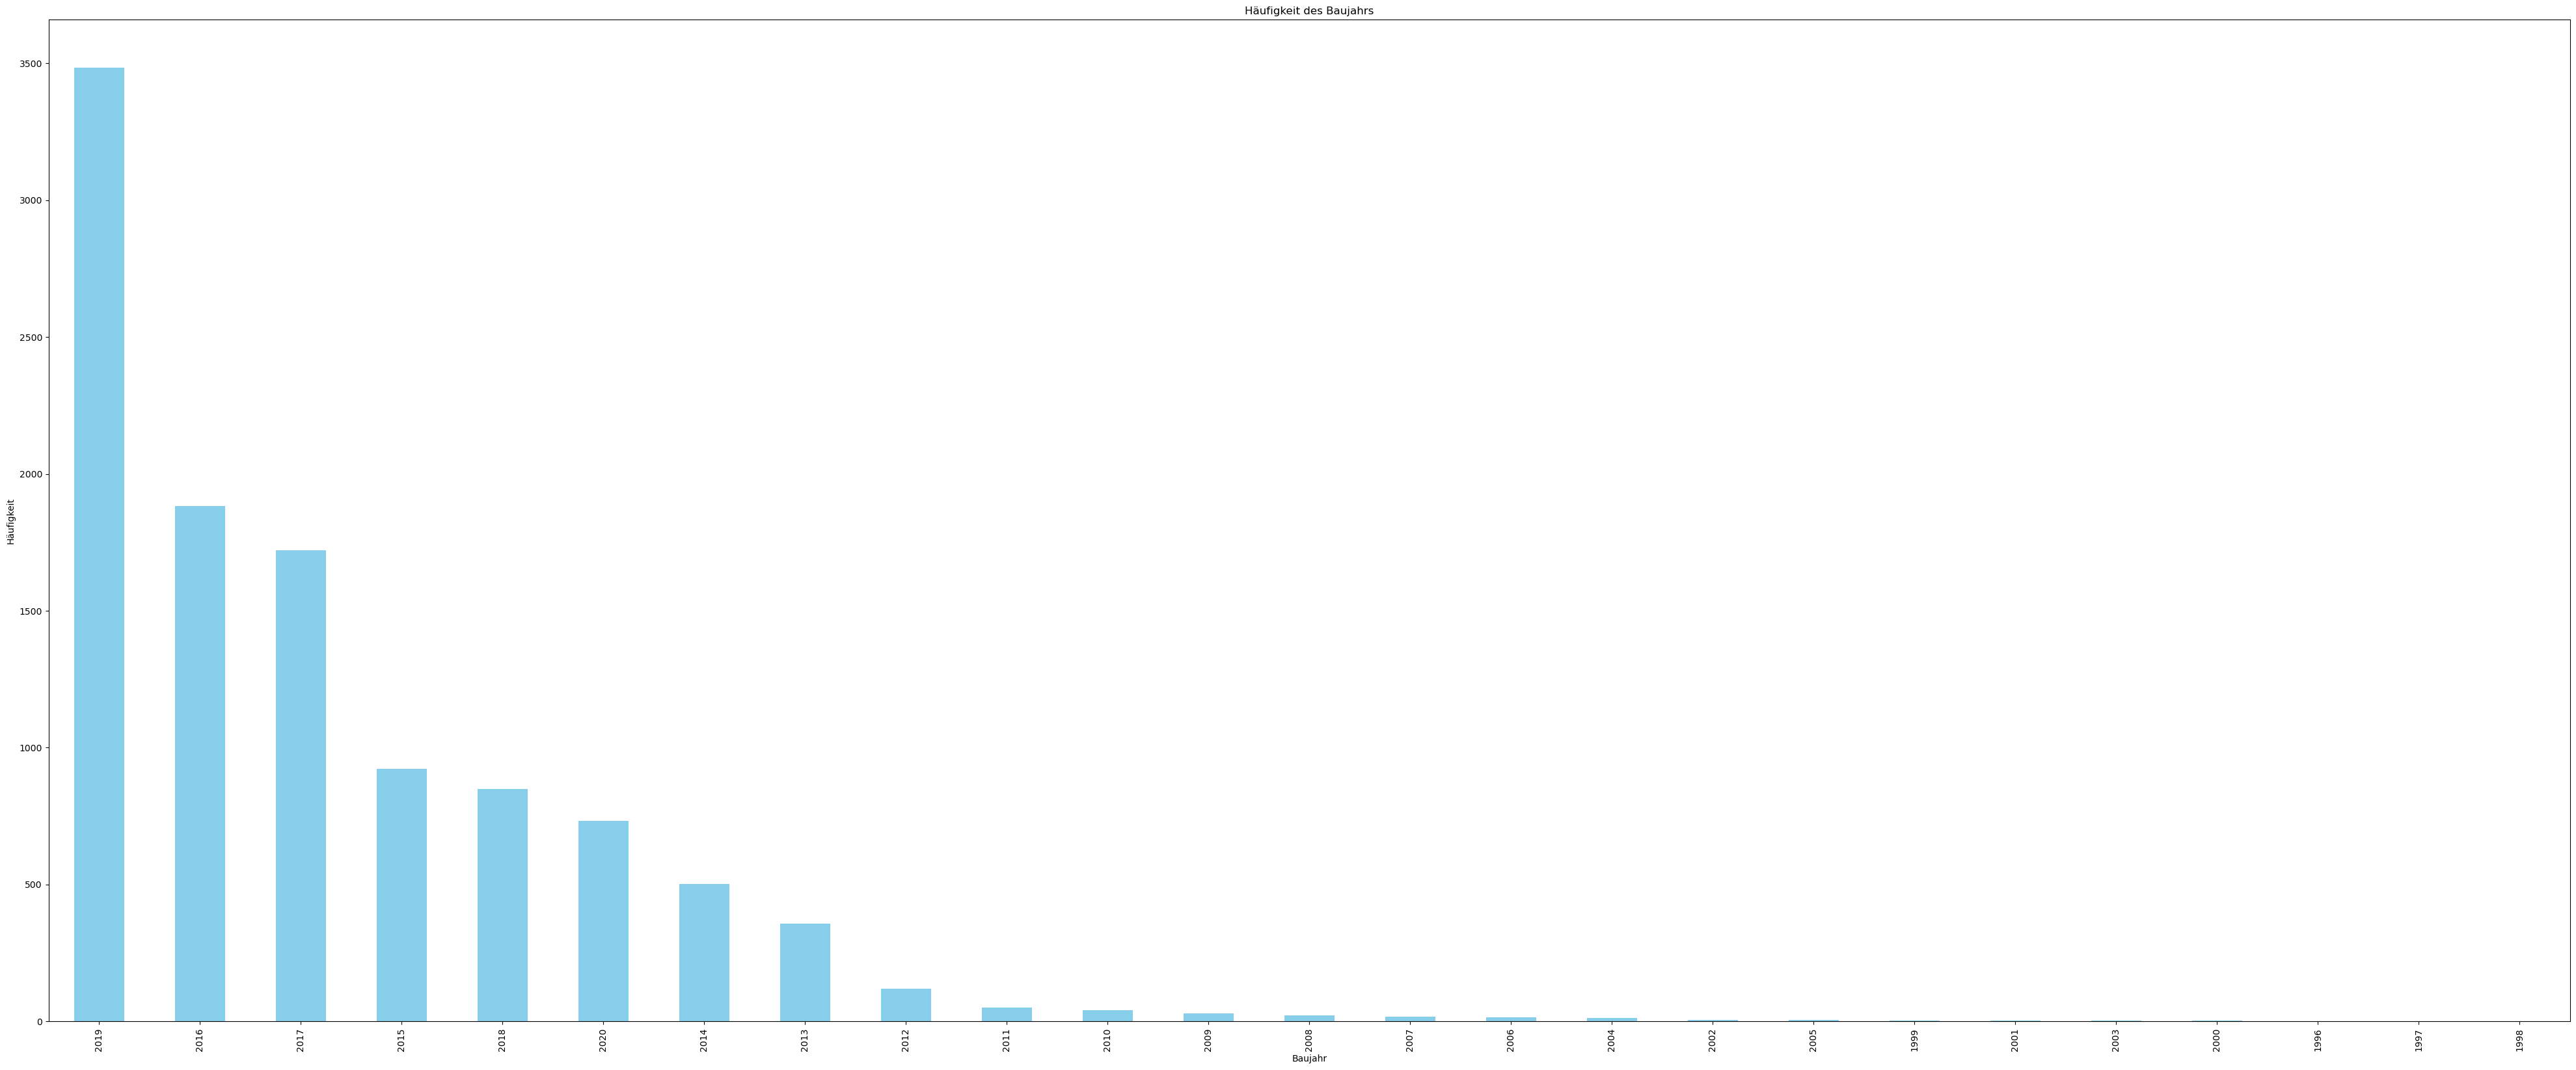

In [42]:
# Häufigkeiten der einzigartigen Werte einer Spalte berechnen
haeufigkeiten = uc_bmw['year'].value_counts()

# Balkendiagramm erstellen
haeufigkeiten.plot(kind='bar', color='skyblue')

# Titel und Achsenbezeichner hinzufügen
plt.title('Häufigkeit des Baujahrs')
plt.xlabel('Baujahr')
plt.ylabel('Häufigkeit')

# Diagramm anzeigen
plt.show()

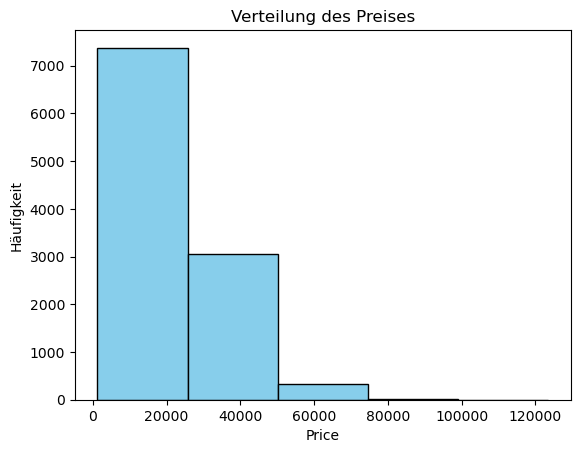

In [14]:
# Histogramm estellen

uc_bmw['price'].plot(kind='hist', bins=5, color='skyblue', edgecolor='black')

# Titel und Achsenbezeichner hinzufügen
plt.title('Verteilung des Preises')
plt.xlabel('Price')
plt.ylabel('Häufigkeit')

# Diagramm anzeigen
plt.show()

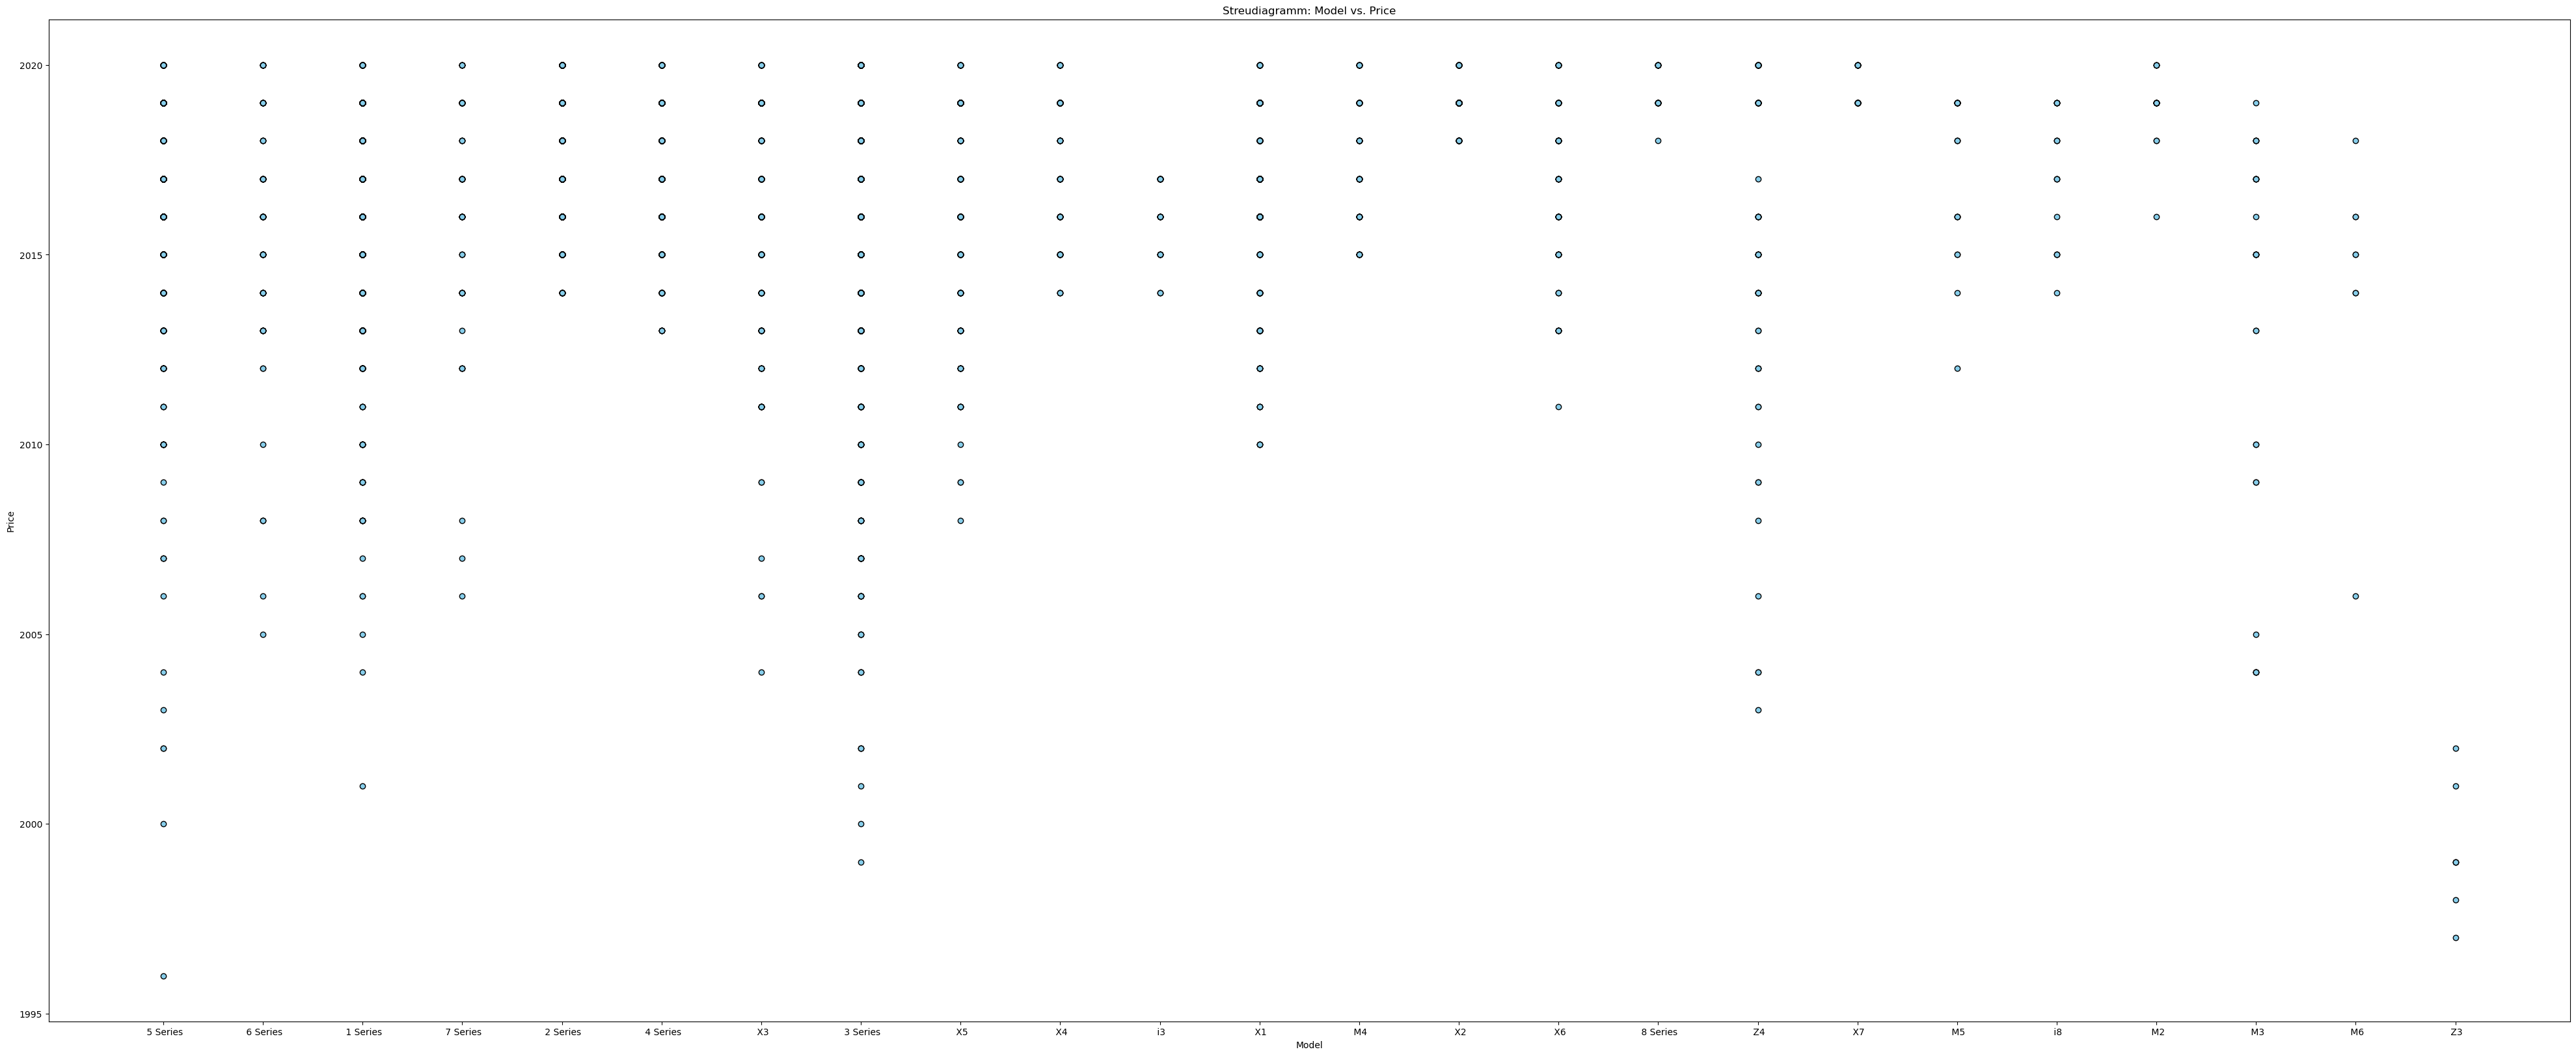

In [43]:
# Streudiagramm erstellen
plt.scatter(uc_bmw['model'], uc_bmw['year'], color='skyblue', edgecolor='black')
plt.rc('figure', figsize=(10, 50))

# Titel und Achsenbezeichner hinzufügen
plt.title('Streudiagramm: Model vs. Price')
plt.xlabel('Model')
plt.ylabel('Price')

# Diagramm anzeigen
plt.show()

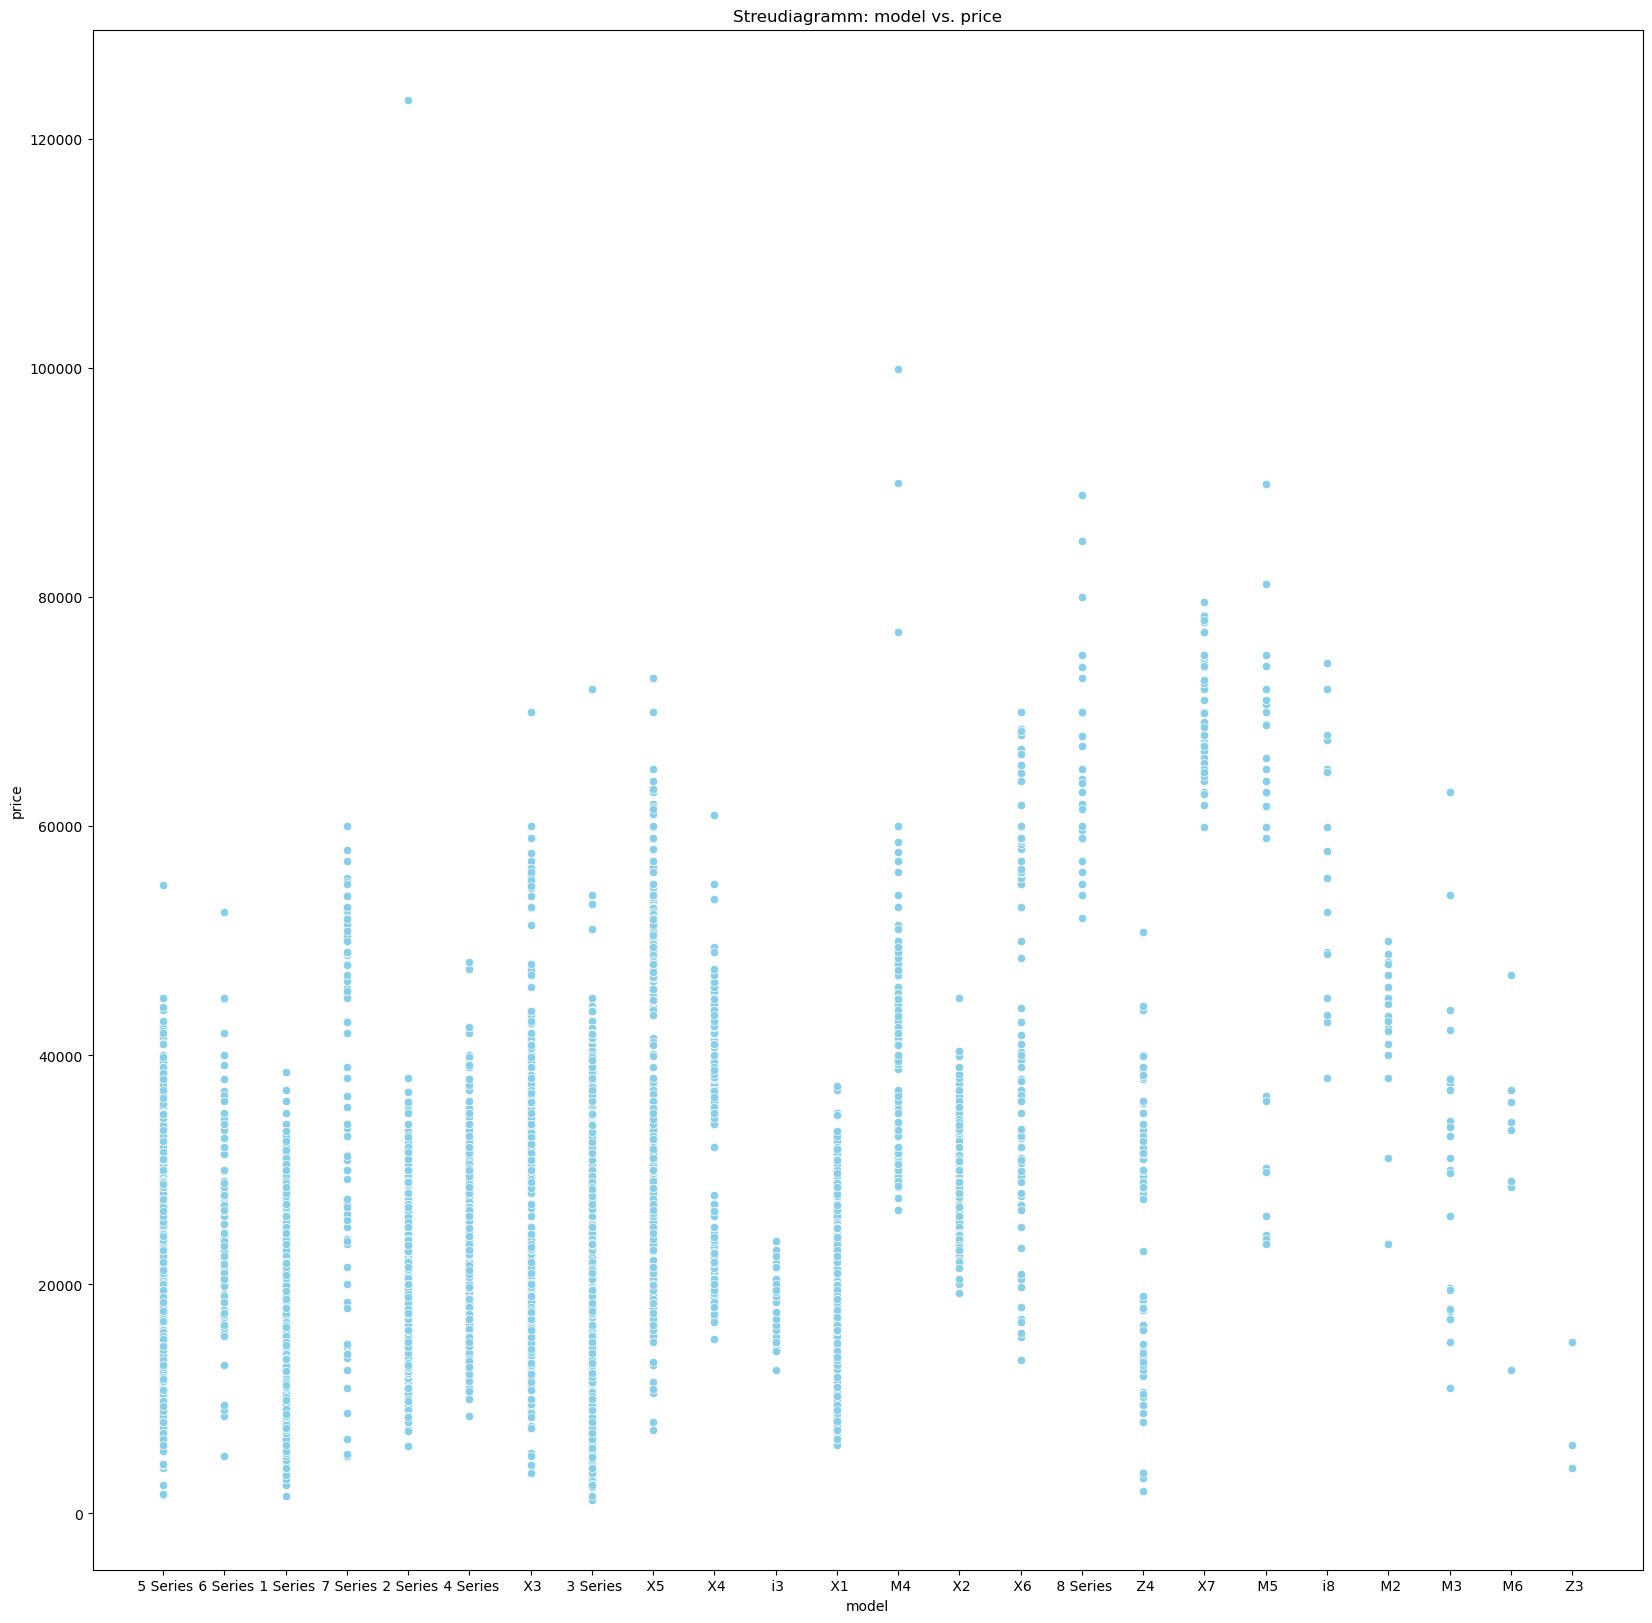

In [40]:
import seaborn as sns

# Streudiagramm mit seaborn erstellen
sns.scatterplot(data=uc_bmw, x='model', y='price', color='skyblue')
plt.rc('figure', figsize=(50, 20))

# Titel hinzufügen
plt.title('Streudiagramm: model vs. price')

# Diagramm anzeigen
plt.show()

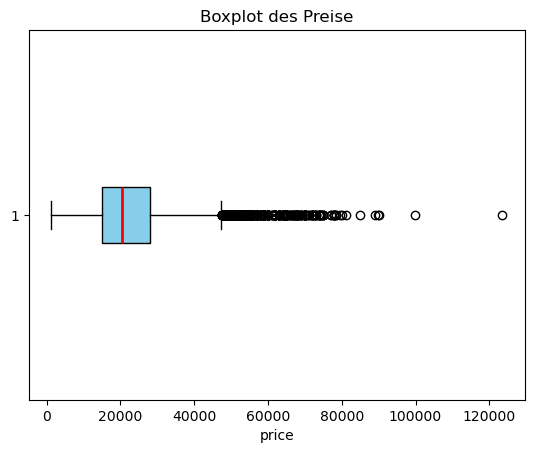

In [ ]:
# Boxplot erstellen
plt.boxplot(uc_bmw['price'], vert=False, patch_artist=True, 
            boxprops=dict(facecolor='skyblue', color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2))

# Titel und Achsenbezeichner hinzufügen
plt.title('Boxplot des Preise')
plt.xlabel('price')

# Diagramm anzeigen
plt.show()

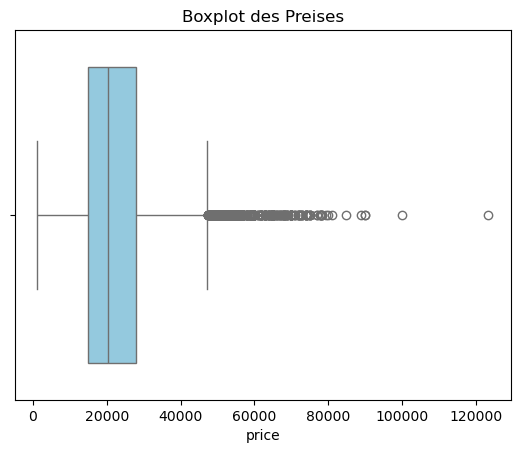

In [18]:
# Boxplot mit seaborn erstellen
sns.boxplot(x=uc_bmw['price'], color='skyblue')

# Titel hinzufügen
plt.title('Boxplot des Preises')

# Diagramm anzeigen
plt.show()

C:\Users\sangermann\AppData\Local\Temp\ipykernel_29112\1087301426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='model', y='price', data=uc_bmw, palette='Set2')


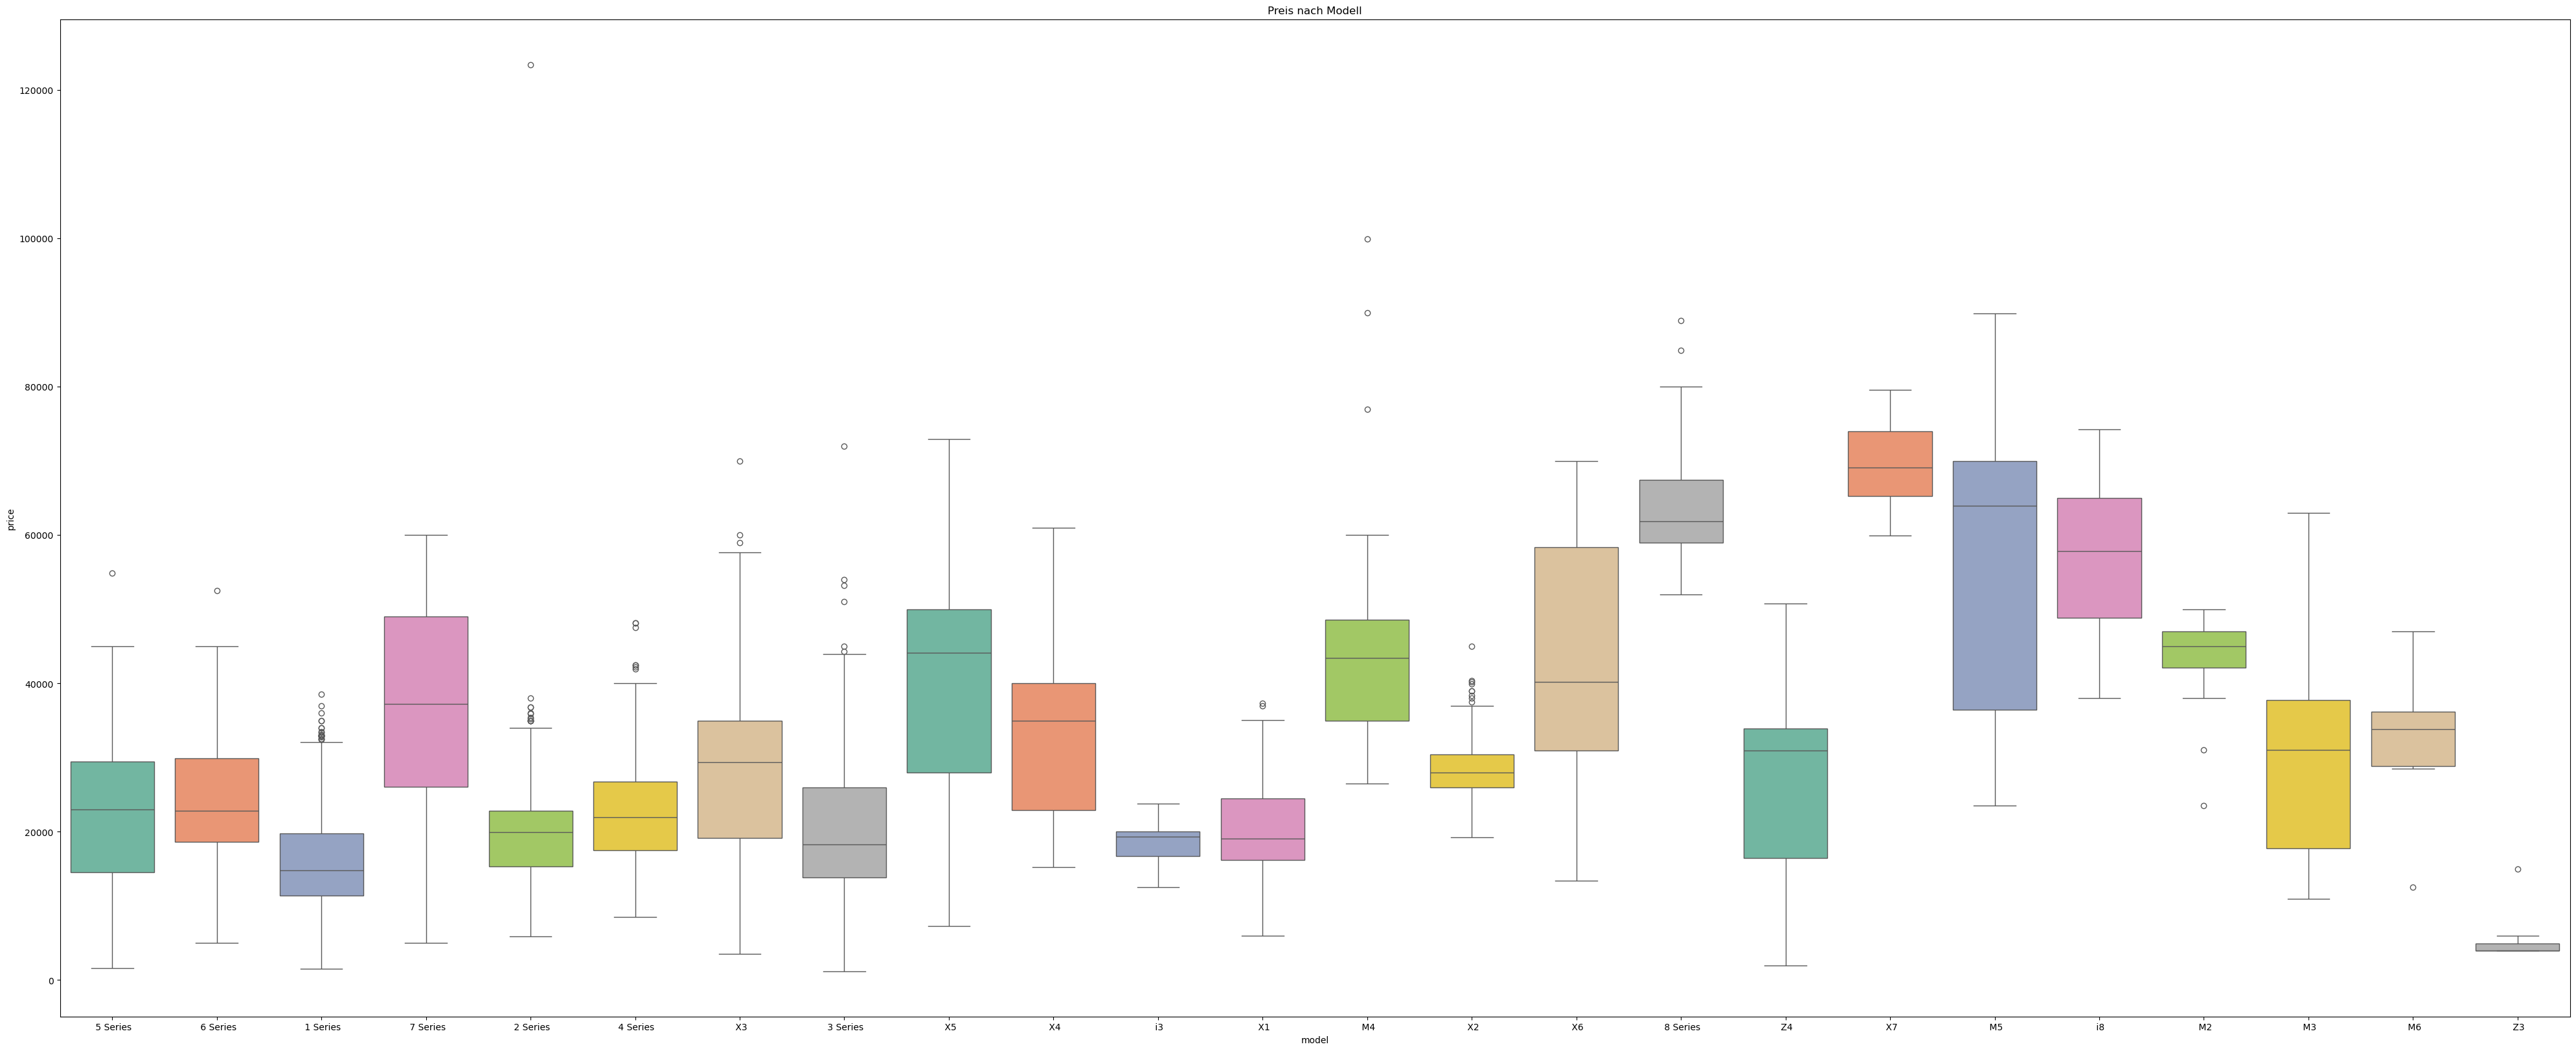

In [41]:
# Boxplot für mehrere Gruppen
sns.boxplot(x='model', y='price', data=uc_bmw, palette='Set2')
plt.rc('figure', figsize=(50, 20))

# Titel hinzufügen
plt.title('Preis nach Modell')

# Diagramm anzeigen
plt.show()

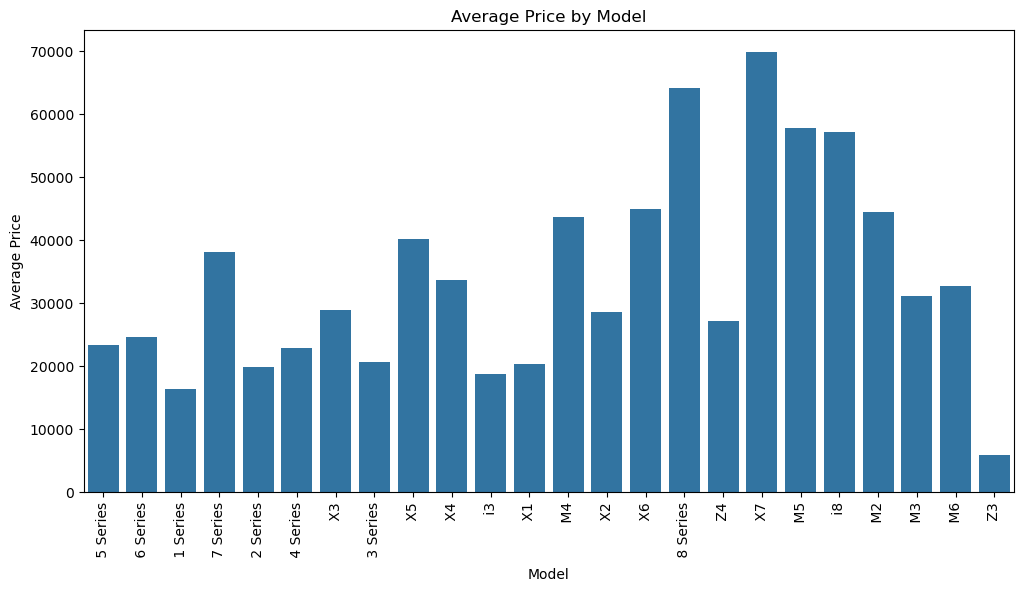

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x='model', y='price', data=uc_bmw[:10000], errorbar=None)
plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=90)  
plt.show()